In [1]:
import sys, pickle, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
sys.path.append('..')
from src.models.model_training import ModelTrainer
from config.settings import *
print("🤖 Step 3: Model Development & Training")


✅ Config loaded
🤖 Step 3: Model Development & Training


In [2]:
print("📁 Loading features...")
with open('../models/features.pkl', 'rb') as f:
    fd = pickle.load(f)
X_train, X_test = fd['X_train'], fd['X_test']
y_train, y_test = fd['y_train'], fd['y_test']
feature_names = fd['feature_names']
print(f"✅ Train: {X_train.shape[0]:,} × {X_train.shape[1]:,} | Test: {X_test.shape[0]:,} × {X_test.shape[1]:,}")


📁 Loading features...
✅ Train: 76,017 × 10,000 | Test: 19,005 × 10,000


In [3]:
trainer = ModelTrainer()
# Quick sanity run on subset if needed:
# trainer.train_all_models(X_train[:20000], y_train[:20000])
trainer.train_all_models(X_train, y_train)
print("✅ All models trained")


✅ ModelTrainer ready (LogReg, NB, Linear SVM, SGD-LogReg, RF + Ensemble)
🏋️ Training models...
🔄 Training Logistic Regression...
✅ Logistic Regression trained
🔄 Training Naive Bayes...
✅ Naive Bayes trained
🔄 Training Linear SVM...
✅ Linear SVM trained
🔄 Training SGD-LogReg...
✅ SGD-LogReg trained
🔄 Training Random Forest...
✅ Random Forest trained
🔄 Training Ensemble...
✅ Ensemble trained
✅ All models trained


In [4]:
results = trainer.evaluate_models(X_test, y_test)
comp = trainer.get_model_comparison()
print("\n📈 Model Performance:")
print(comp.to_string(index=False))
best_model = comp.iloc[0]['Model']; best_acc = comp.iloc[0]['Accuracy']
print(f"\n🏆 Best: {best_model} ({best_acc:.2f}%)")


📊 Evaluating models...
✅ Logistic Regression: 75.22%
✅ Naive Bayes: 73.75%
✅ Linear SVM: 73.79%
✅ SGD-LogReg: 74.20%
✅ Random Forest: 72.89%
✅ Ensemble: 74.80%

📈 Model Performance:
              Model  Accuracy
Logistic Regression 75.217048
           Ensemble 74.801368
         SGD-LogReg 74.196264
         Linear SVM 73.791108
        Naive Bayes 73.749013
      Random Forest 72.891344

🏆 Best: Logistic Regression (75.22%)


In [5]:
print("🔄 5-fold cross-validation (train set)...")
cv = trainer.cross_validate_models(X_train, y_train, cv_folds=5)
cv_df = pd.DataFrame({'Model': list(cv.keys()),
                      'CV_Mean': [v['mean']*100 for v in cv.values()],
                      'CV_Std': [v['std']*100 for v in cv.values()]})
print(cv_df.to_string(index=False))


🔄 5-fold cross-validation (train set)...
🔄 5-fold cross-validation (skip Ensemble for speed)...
✅ Logistic Regression: 74.51% ± 0.19%
✅ Naive Bayes: 73.37% ± 0.30%
✅ Linear SVM: 73.10% ± 0.08%
✅ SGD-LogReg: 74.05% ± 0.28%
✅ Random Forest: 72.85% ± 0.39%
              Model   CV_Mean   CV_Std
Logistic Regression 74.513599 0.192618
        Naive Bayes 73.374372 0.304058
         Linear SVM 73.099440 0.075136
         SGD-LogReg 74.045283 0.280064
      Random Forest 72.852128 0.387157


In [6]:
print("🔧 Tuning and retraining...")
trainer.tune_hyperparameters(X_train, y_train)
trainer.train_all_models(X_train, y_train)
tuned = trainer.evaluate_models(X_test, y_test)
tuned_comp = trainer.get_model_comparison()
print("\n📈 Tuned Performance:")
print(tuned_comp.to_string(index=False))


🔧 Tuning and retraining...
🔧 Hyperparameter tuning (small, practical grids)...
🔧 Tuning Logistic Regression...


C:\Res_Projects\social_media_sentiment_analysis\sentiment_analysis_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1305: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 12.
  warnings.warn(


✅ Best Logistic Regression: {'C': 0.5, 'solver': 'liblinear'} (CV 74.31%)
🔧 Tuning Naive Bayes...
✅ Best Naive Bayes: {'alpha': 1.5} (CV 73.24%)
🔧 Tuning Linear SVM...
✅ Best Linear SVM: {'C': 0.5} (CV 73.27%)
🔧 Tuning SGD-LogReg...
✅ Best SGD-LogReg: {'alpha': 1e-05} (CV 74.09%)
🔧 Tuning Random Forest...
✅ Best Random Forest: {'max_depth': None, 'n_estimators': 200} (CV 72.67%)
✅ Ensemble retrained with tuned models
🏋️ Training models...
🔄 Training Logistic Regression...


C:\Res_Projects\social_media_sentiment_analysis\sentiment_analysis_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1305: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 12.
  warnings.warn(


✅ Logistic Regression trained
🔄 Training Naive Bayes...
✅ Naive Bayes trained
🔄 Training Linear SVM...
✅ Linear SVM trained
🔄 Training SGD-LogReg...
✅ SGD-LogReg trained
🔄 Training Random Forest...
✅ Random Forest trained
🔄 Training Ensemble...
✅ Ensemble trained
📊 Evaluating models...
✅ Logistic Regression: 75.09%
✅ Naive Bayes: 73.78%
✅ Linear SVM: 74.38%
✅ SGD-LogReg: 75.01%
✅ Random Forest: 73.00%
✅ Ensemble: 74.91%

📈 Tuned Performance:
              Model  Accuracy
Logistic Regression 75.090766
         SGD-LogReg 75.006577
           Ensemble 74.911865
         Linear SVM 74.375164
        Naive Bayes 73.780584
      Random Forest 72.996580



📊 Classification Report: Logistic Regression
              precision    recall  f1-score   support

    Negative       0.77      0.73      0.75      9561
    Positive       0.74      0.77      0.76      9444

    accuracy                           0.75     19005
   macro avg       0.75      0.75      0.75     19005
weighted avg       0.75      0.75      0.75     19005


Confusion Matrix:
 [[6958 2603]
 [2131 7313]]


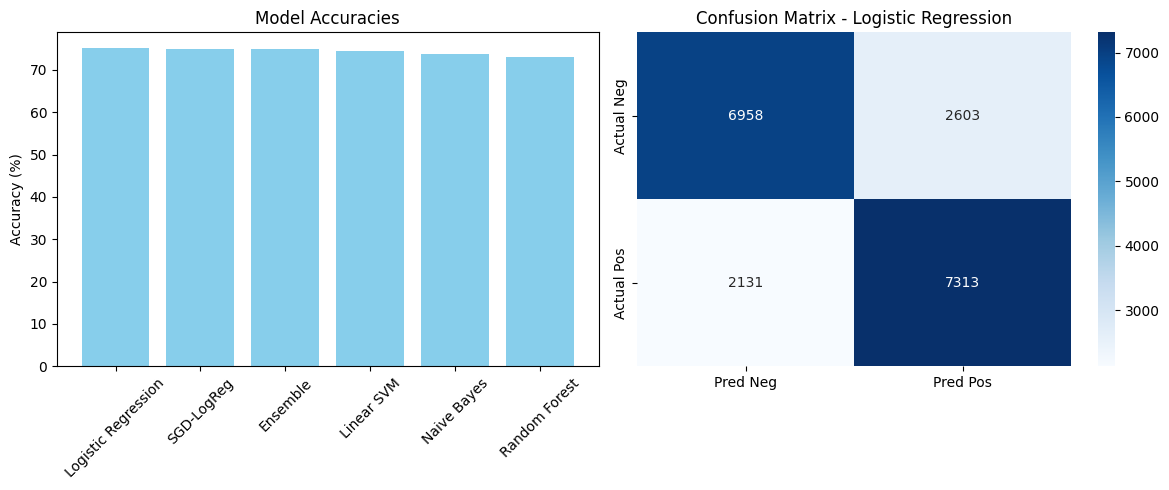

In [7]:
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
best_name = tuned_comp.iloc[0]['Model']
bm = trainer.trained_models[best_name]
y_pred = bm.predict(X_test)
print(f"\n📊 Classification Report: {best_name}")
print(classification_report(y_test, y_pred, target_names=['Negative','Positive']))
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# Quick plots
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(12,5))
ax1.bar(tuned_comp['Model'], tuned_comp['Accuracy'], color='skyblue')
ax1.set_title('Model Accuracies'); ax1.set_ylabel('Accuracy (%)'); ax1.tick_params(axis='x', rotation=45)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2, xticklabels=['Pred Neg','Pred Pos'], yticklabels=['Actual Neg','Actual Pos'])
ax2.set_title(f'Confusion Matrix - {best_name}')
plt.tight_layout(); plt.show()


In [8]:
trainer.save_models()
tuned_comp.to_csv('../data/processed/model_comparison.csv', index=False)
with open('../models/detailed_results.pkl', 'wb') as f:
    pickle.dump({
        'best_model': best_name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'confusion_matrix': cm.tolist(),
    }, f)
print("💾 Saved comparison CSV and detailed results.")


💾 Saved trained_models.pkl and model_results.pkl
💾 Saved comparison CSV and detailed results.


In [10]:
# Cell 8: Save models and results
print("💾 Saving all trained models and results...")

# Save trained models
trainer.save_models()

# Save comparison results
comparison_file = '../data/processed/model_comparison.csv'
tuned_comp.to_csv(comparison_file, index=False)  # FIXED: Changed tuned_comparison to tuned_comp
print(f"💾 Saved model comparison to: {comparison_file}")

# Get best model info (already defined from Cell 4)
best_name = tuned_comp.iloc[0]['Model']
best_acc = tuned_comp.iloc[0]['Accuracy']

# Get predictions from best model
best_model_obj = trainer.trained_models[best_name]
y_pred_best = best_model_obj.predict(X_test)

# Calculate metrics
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

# Save detailed results
detailed_results = {
    'best_model': best_name,
    'best_accuracy': best_acc,
    'accuracy': accuracy_score(y_test, y_pred_best) * 100,
    'precision': precision_score(y_test, y_pred_best) * 100,
    'recall': recall_score(y_test, y_pred_best) * 100,
    'f1_score': f1_score(y_test, y_pred_best) * 100,
    'classification_report': classification_report(y_test, y_pred_best, output_dict=True),
    'confusion_matrix': confusion_matrix(y_test, y_pred_best).tolist(),
    'all_results': tuned  # FIXED: Changed tuned_results to tuned
}

with open('../models/detailed_results.pkl', 'wb') as f:
    pickle.dump(detailed_results, f)

print(f"💾 Saved detailed results to: ../models/detailed_results.pkl")

print(f"\n🎉 Step 3 Complete!")
print(f"\n📊 Final Summary:")
print(f"   ✅ Trained 5 different classifiers")
print(f"   ✅ Performed 5-fold cross-validation")
print(f"   ✅ Completed hyperparameter tuning")
print(f"   ✅ Best model: {best_name} ({best_acc:.2f}%)")
print(f"   ✅ All models and results saved")

print(f"\n🚀 Ready for Step 4: Model Evaluation & Deployment!")


💾 Saving all trained models and results...
💾 Saved trained_models.pkl and model_results.pkl
💾 Saved model comparison to: ../data/processed/model_comparison.csv
💾 Saved detailed results to: ../models/detailed_results.pkl

🎉 Step 3 Complete!

📊 Final Summary:
   ✅ Trained 5 different classifiers
   ✅ Performed 5-fold cross-validation
   ✅ Completed hyperparameter tuning
   ✅ Best model: Logistic Regression (75.09%)
   ✅ All models and results saved

🚀 Ready for Step 4: Model Evaluation & Deployment!
